In [ ]:
##

In [ ]:
#1.What is unsupervised learning in the context of machine learning.
Unsupervised learning involves training a model on data without labeled outcomes. 
The goal is to uncover hidden patterns or structures in the data, 
such as grouping similar data points together (clustering) or reducing data dimensions (dimensionality reduction).

In [ ]:
#2.How does K-Means clustering algorithm work.
K-Means is a partition-based clustering algorithm that works as follows:
Choose the number of clusters, K.
Randomly initialize K centroids.
Assign each data point to the nearest centroid.
Recalculate the centroids as the mean of all points assigned to each cluster.
Repeat steps 3–4 until centroids no longer change significantly.

In [ ]:
#3.Explain the concept of a dendrogram in hierarchical clustering.
A dendrogram is a tree-like diagram that shows the hierarchical relationships among data points.
In agglomerative clustering, it starts with each point as its own cluster and merges the closest clusters step by step.
The dendrogram helps visualize cluster distances and choose the optimal number of clusters by cutting the tree at a specific height.

In [ ]:
#4.What is the main difference between K-Means and Hierarchical Clustering.
K-Means requires a predefined number of clusters and works well on large datasets.
Hierarchical Clustering doesn’t require specifying the number of clusters upfront and creates a hierarchy,
but is more computationally expensive and not scalable to large datasets.

In [ ]:
#5.What are the advantages of DBSCAN over K-Means.
No need to specify the number of clusters beforehand.
Can find arbitrarily shaped clusters.
Identifies noise/outliers as separate from clusters.
Works better on datasets with varying densities.

In [ ]:
#6.When would you use Silhouette Score in clustering.
Silhouette Score is used to evaluate the quality of clustering.
It measures how similar an object is to its own cluster vs. others. Use it to:
Determine the optimal number of clusters.
Compare clustering performance between different algorithms.

In [ ]:
#7.What are the limitations of Hierarchical Clustering.
Scales poorly with large datasets (high computational cost).
Once a merge or split is made, it cannot be undone.
Sensitive to noise and outliers.
Difficult to determine the correct number of clusters visually from the dendrogram.

In [ ]:
#8.why is feature scaling important in clustering algorithms like K-Means.
K-Means relies on Euclidean distance, which is sensitive to feature magnitudes. 
Feature scaling ensures all features contribute equally, preventing dominant features from skewing the clustering results.

In [ ]:
#9.How does DBSCAN identify noise points.
DBSCAN classifies points as:
Core Points: have enough neighboring points (minPts within ε distance).
Border Points: not core points, but within ε of a core point.
Noise Points: neither core nor border — these are considered outliers.

In [ ]:
#10.fine inertia in the context of K-Means.
Inertia measures the sum of squared distances between each data point and its assigned cluster centroid. 
It quantifies how tight the clusters are — lower inertia means denser clusters and 
generally better clustering (though too low might mean overfitting).

In [ ]:
#11. What is the elbow method in K-Means clustering?
The elbow method helps determine the optimal number of clusters (K) by plotting the within-cluster sum of squares (inertia)
against different K values. The "elbow" point, where the rate of decrease sharply slows, 
suggests a good trade-off between cluster compactness and model complexity.

In [ ]:
#12. Describe the concept of "density" in DBSCAN.
In DBSCAN, density refers to the number of data points within a specified radius (ε).
Clusters are formed in high-density areas, while low-density regions are treated as noise or outliers.

In [ ]:
#13.Can hierarchical clustering be used on categorical data?
Yes, but it requires an appropriate distance metric like Hamming distance or Gower distance. 
Standard Euclidean-based methods don’t work well directly on categorical data.

In [ ]:
#14.What does a negative Silhouette Score indicate?
A negative score means a sample is likely assigned to the wrong cluster—its average distance to points in 
its own cluster is higher than to those in a neighboring cluster.

In [ ]:
#15.Explain the term "linkage criteria" in hierarchical clustering.
Linkage criteria define how distances between clusters are calculated:
Single linkage: nearest pair of points.
Complete linkage: farthest pair of points.
Average linkage: average distance between all pairs.
Ward’s method: minimizes variance within clusters.

In [ ]:
#16.Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?
K-Means assumes equal-sized, spherical clusters with similar densities. It struggles with:
Uneven cluster sizes
Varying densities
Non-globular shapes This can lead to inaccurate cluster assignments.

In [ ]:
#17.What are the core parameters in DBSCAN, and how do they influence clustering?

ε (epsilon): Maximum distance to consider points as neighbors.
minPts: Minimum number of points required to form a dense region.
These control what constitutes a cluster and affect sensitivity to noise and outlier detection.

In [ ]:
#18. How does K-Means++ improve upon standard K-Means initialization?
K-Means++ spreads out initial cluster centers more intelligently by selecting new centers based on distance from existing ones.
This reduces chances of poor clustering due to bad initialization.

In [ ]:
#19.What is agglomerative clustering?
A bottom-up hierarchical clustering method where each point starts as its own cluster, 
and pairs of clusters are merged iteratively based on a linkage criterion until all points form a single cluster 
or a stopping condition is met.

In [ ]:
#20.What makes Silhouette Score a better metric than just inertia for model evaluation?
Inertia only measures compactness of clusters, not how well-separated they are. Silhouette Score combines cohesion and 
separation, offering a more balanced view of cluster quality.

In [ ]:
##PRACTICAL_EXAMPLES##

C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


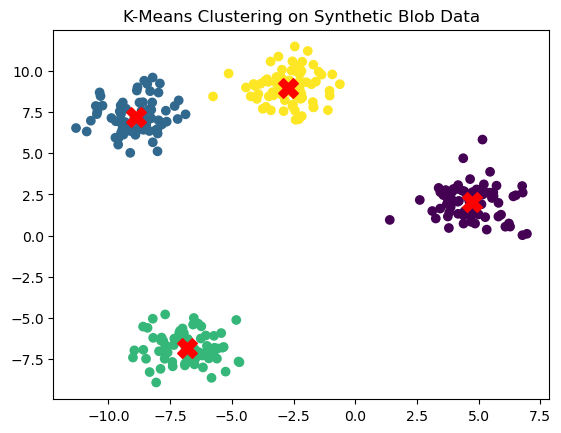

In [2]:
#21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=4, random_state=42)
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.title("K-Means Clustering on Synthetic Blob Data")
plt.show()

In [3]:
 #22. Load the Iris dataset and use Agglomerative Clustering to group into 3 clusters. Display the first 10 predicted labels

from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
X = iris.data

agg_clust = AgglomerativeClustering(n_clusters=3)
labels = agg_clust.fit_predict(X)

print("First 10 predicted labels:", labels[:10])

First 10 predicted labels: [1 1 1 1 1 1 1 1 1 1]


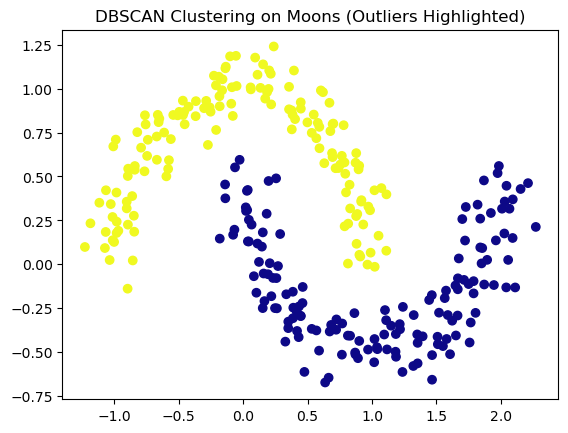

In [4]:
#23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import numpy as np

X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Mark core points, border points, and outliers
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', marker='o')
plt.title("DBSCAN Clustering on Moons (Outliers Highlighted)")
plt.show()

In [5]:
#24. Load the Wine dataset, standardize features, apply K-Means, print size of each cluster

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import numpy as np

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

unique, counts = np.unique(labels, return_counts=True)
print("Cluster sizes:", dict(zip(unique, counts)))

C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster sizes: {0: 51, 1: 62, 2: 65}


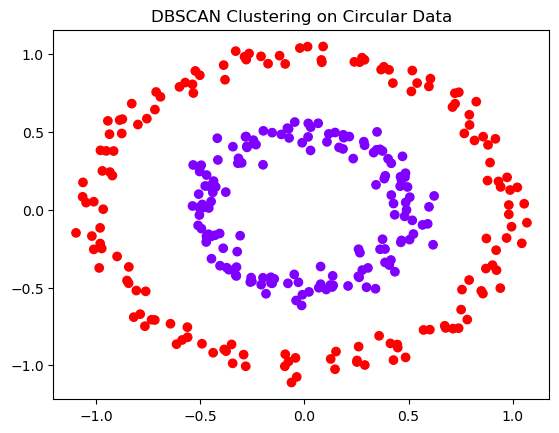

In [6]:
#25.Use make_circles to generate data and cluster with DBSCAN. Plot result

from sklearn.datasets import make_circles

X, _ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.title("DBSCAN Clustering on Circular Data")
plt.show()

In [7]:
#26.Load Breast Cancer dataset, apply MinMaxScaler, use K-Means with 2 clusters. Output centroids

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler

cancer = load_breast_cancer()
X = MinMaxScaler().fit_transform(cancer.data)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)
print("Cluster centroids:\n", kmeans.cluster_centers_)

C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Cluster centroids:
 [[0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]
 [0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]]


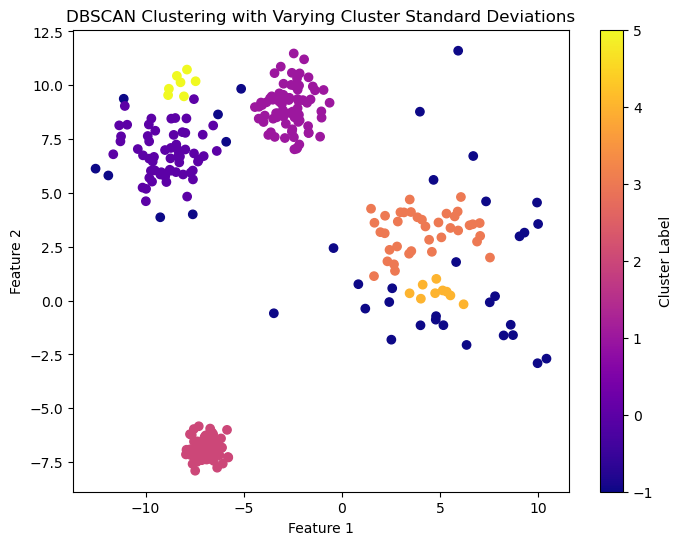

In [8]:
#27.Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN

# Import necessary libraries
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate synthetic data with varying standard deviations
X_varied, y_varied = make_blobs(n_samples=300, centers=4,
                                 cluster_std=[1.0, 2.5, 0.5, 1.5],
                                 random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=1.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_varied)

# Plot DBSCAN results
plt.figure(figsize=(8, 6))
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=labels_dbscan, cmap='plasma')
plt.title("DBSCAN Clustering with Varying Cluster Standard Deviations")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Cluster Label')
plt.show()


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


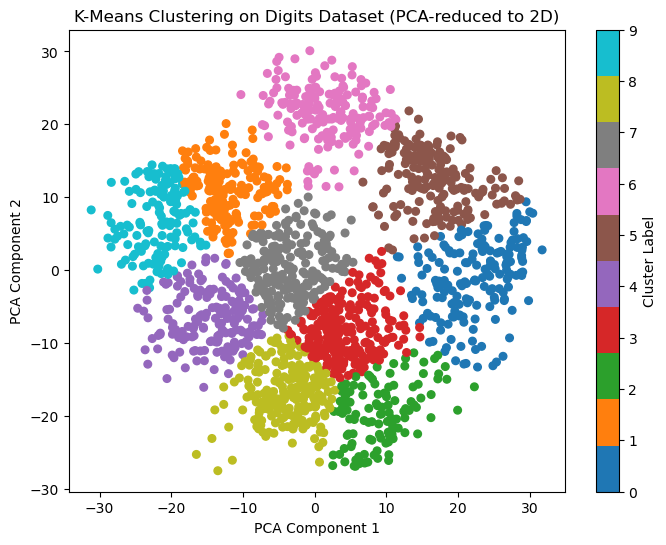

In [9]:
#28.Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load the digits dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_digits)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

# Plot KMeans clustering results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='tab10', s=30)
plt.title("K-Means Clustering on Digits Dataset (PCA-reduced to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster Label')
plt.show()


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


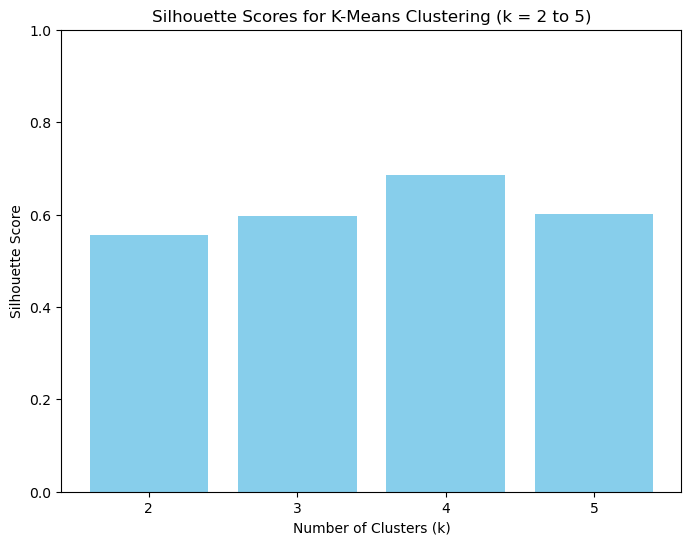

In [11]:
# Task 3: Create synthetic data and evaluate silhouette scores for k = 2 to 5

from sklearn.metrics import silhouette_score

# Generate synthetic data
X_silhouette, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)

# Evaluate silhouette scores for k = 2 to 5
silhouette_scores = []
k_values = range(2, 6)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_silhouette)
    score = silhouette_score(X_silhouette, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(8, 6))
plt.bar(k_values, silhouette_scores, color='skyblue')
plt.title("Silhouette Scores for K-Means Clustering (k = 2 to 5)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.ylim(0, 1)
plt.show()


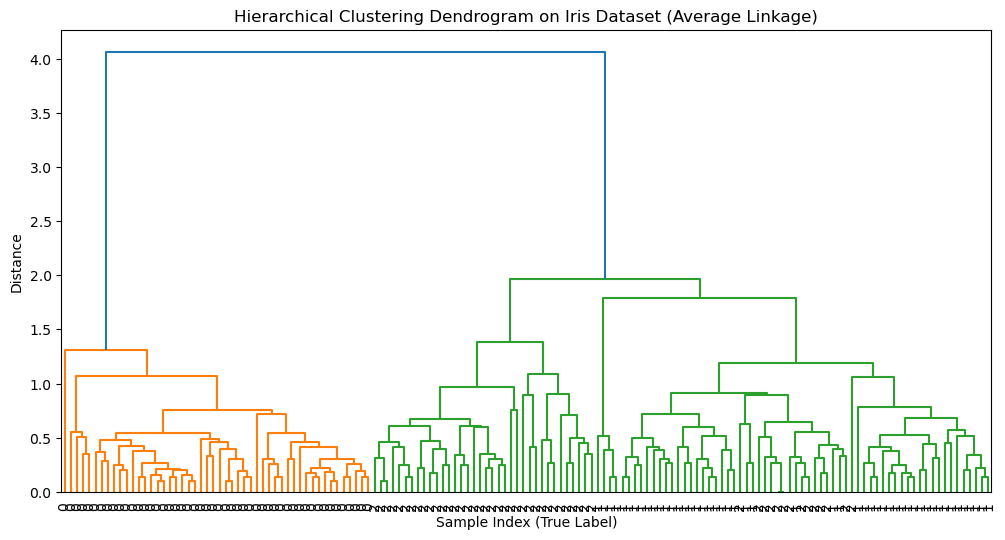

In [12]:
# Task 4: Hierarchical clustering on Iris dataset with dendrogram (average linkage)

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X_iris = iris.data

# Compute linkage matrix using average linkage
linked = linkage(X_iris, method='average')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           labels=iris.target,
           leaf_rotation=90,
           leaf_font_size=10,
           color_threshold=0.7 * max(linked[:, 2]))
plt.title("Hierarchical Clustering Dendrogram on Iris Dataset (Average Linkage)")
plt.xlabel("Sample Index (True Label)")
plt.ylabel("Distance")
plt.show()


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


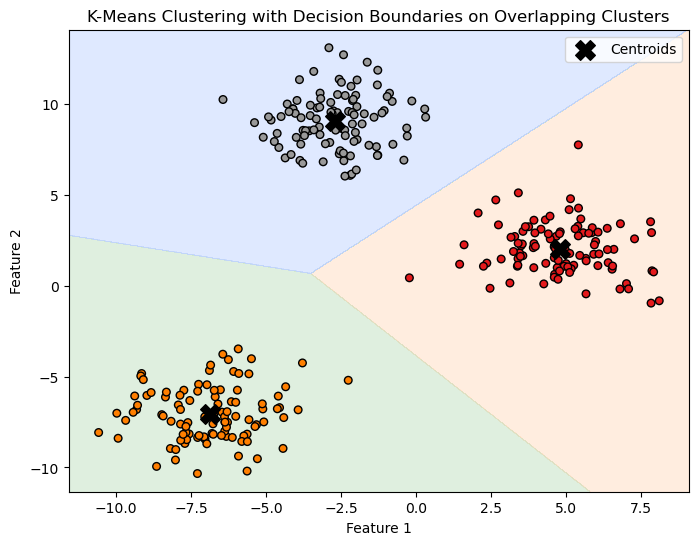

In [13]:
#31.K-Means Clustering with Decision Boundaries on Overlapping Clusters: This plot visualizes how K-Means clustering handles overlapping clusters, showing the decision boundaries and the clustered points.
# Task 5: K-Means Clustering with Decision Boundaries on Overlapping Clusters

import numpy as np
from matplotlib.colors import ListedColormap

# Generate synthetic data with overlapping clusters
X_overlap, y_overlap = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=42)

# Fit KMeans clustering
kmeans_overlap = KMeans(n_clusters=3, random_state=42).fit(X_overlap)
y_kmeans = kmeans_overlap.predict(X_overlap)

# Create mesh grid for decision boundary visualization
h = .02  # step size
x_min, x_max = X_overlap[:, 0].min() - 1, X_overlap[:, 0].max() + 1
y_min, y_max = X_overlap[:, 1].min() - 1, X_overlap[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = kmeans_overlap.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries and clustered data
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFDDC1', '#C1E1C1', '#C1D4FF']), alpha=0.5)
plt.scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_kmeans, cmap='Set1', edgecolor='k', s=30)
plt.scatter(kmeans_overlap.cluster_centers_[:, 0], kmeans_overlap.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')
plt.title("K-Means Clustering with Decision Boundaries on Overlapping Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


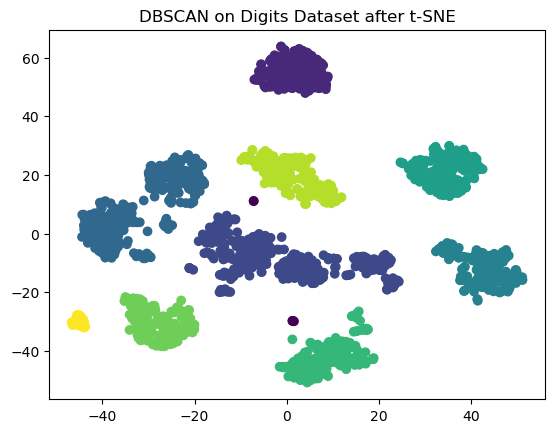

In [19]:
#32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Load the Digits dataset
digits = datasets.load_digits()
X = digits.data

# Reduce dimensions using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=6, min_samples=10)
y_dbscan = dbscan.fit_predict(X_tsne)

# Visualize the results
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_dbscan, cmap='viridis')
plt.title("DBSCAN on Digits Dataset after t-SNE")
plt.show()


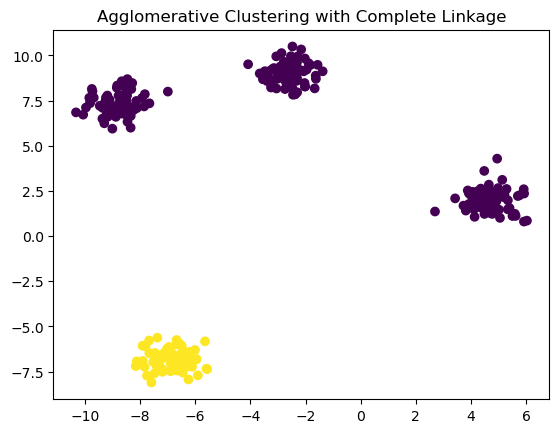

In [21]:
#33.Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in aline plot.
#Agglomerative Clustering on Synthetic Data using make_blobs

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Apply Agglomerative Clustering with complete linkage
agg_clust = AgglomerativeClustering(linkage='complete')
y_agg_clust = agg_clust.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=y_agg_clust, cmap='viridis')
plt.title("Agglomerative Clustering with Complete Linkage")
plt.show()

C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-pa

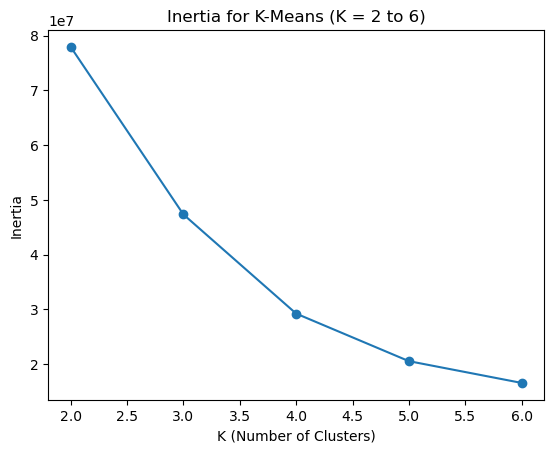

In [22]:
#34.Compare Inertia Values for K-Means with K = 2 to 6 on the Breast Cancer Dataset

from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load the Breast Cancer dataset
cancer = load_breast_cancer()
X = cancer.data

# Calculate inertia for different values of K
inertia = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot inertia values
plt.plot(range(2, 7), inertia, marker='o')
plt.title("Inertia for K-Means (K = 2 to 6)")
plt.xlabel("K (Number of Clusters)")
plt.ylabel("Inertia")
plt.show()

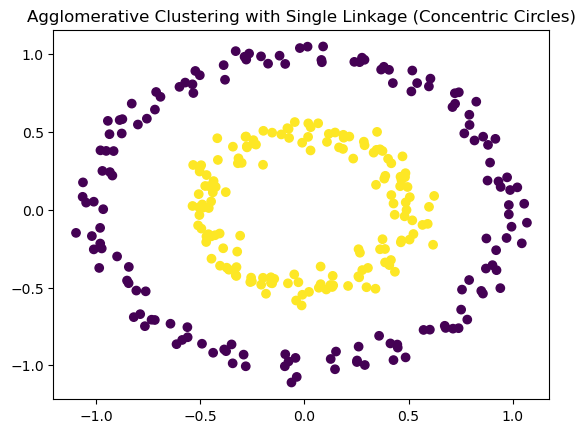

In [23]:
#35.Agglomerative Clustering with Single Linkage on Synthetic Concentric Circles

from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Generate synthetic concentric circles data
X, _ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)

# Apply Agglomerative Clustering with single linkage
agg_clust = AgglomerativeClustering(linkage='single')
y_agg_clust = agg_clust.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=y_agg_clust, cmap='viridis')
plt.title("Agglomerative Clustering with Single Linkage (Concentric Circles)")
plt.show()

In [29]:
#36.Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise).

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Load the Wine dataset
wine = load_wine()
X = wine.data

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN()
dbscan.fit(X_scaled)

# Get the labels from DBSCAN
labels = dbscan.labels_

# Get the unique labels
unique_labels = set(labels)

# Count the number of clusters excluding noise (which is labeled as -1)
num_clusters = len([label for label in unique_labels if label != -1])

print(f"Number of clusters (excluding noise): {num_clusters}")


Number of clusters (excluding noise): 0


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


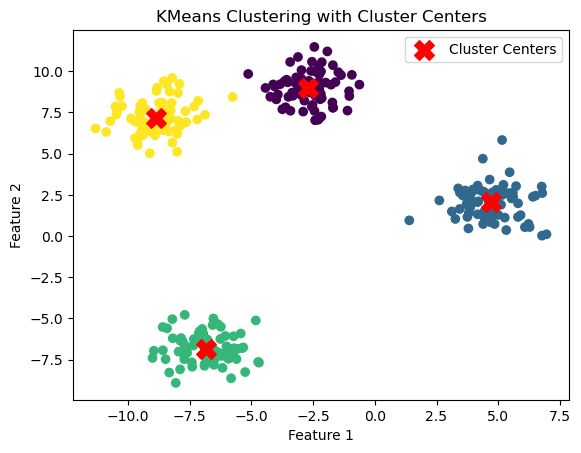

In [30]:
#37.Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic data using make_blobs
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Get the cluster centers
centers = kmeans.cluster_centers_

# Plot the data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o')

# Plot the cluster centers
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='red', marker='X', label='Cluster Centers')

# Add labels and title
plt.title("KMeans Clustering with Cluster Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

# Show the plot
plt.show()


In [31]:
#38.Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise
#Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the
#clustering result

from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data

# Scale the data (important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN()
dbscan.fit(X_scaled)

# Get the labels (noise is labeled as -1)
labels = dbscan.labels_

# Count how many samples were identified as noise (-1)
noise_samples = list(labels).count(-1)

print(f"Number of samples identified as noise: {noise_samples}")


Number of samples identified as noise: 34


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


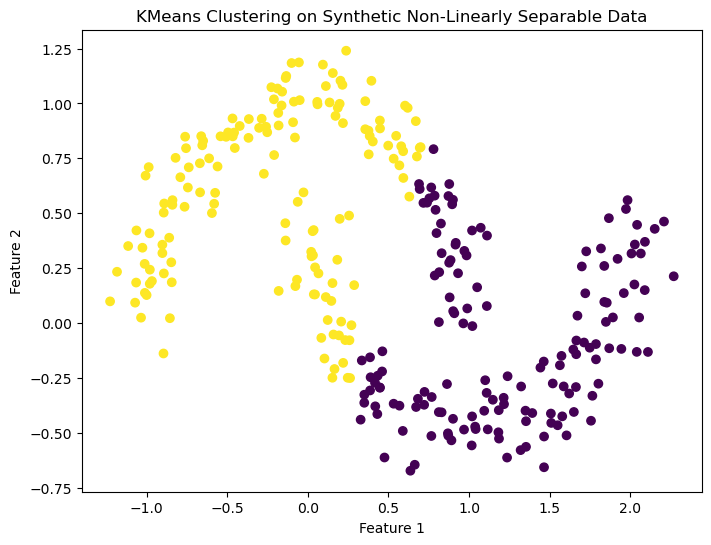

In [32]:
#39.Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D
#scatter plot.

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# Generate synthetic non-linearly separable data using make_moons
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

# Apply K-Means clustering (we assume 2 clusters for simplicity)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# Get the predicted labels
labels = kmeans.labels_

# Plot the clustering result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
plt.title("KMeans Clustering on Synthetic Non-Linearly Separable Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


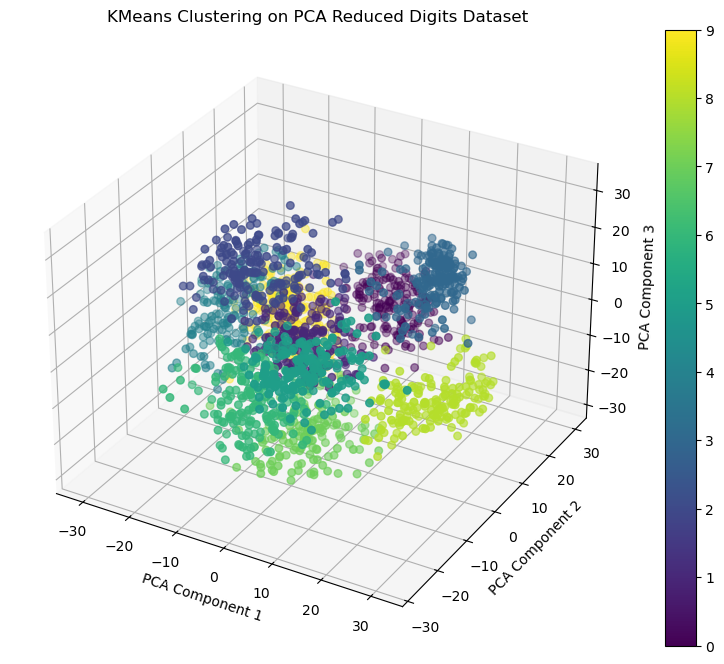

In [33]:
#40.Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.

# Let's first load the Digits dataset, apply PCA to reduce it to 3 components, 
# then use KMeans clustering and visualize the results with a 3D scatter plot.

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load Digits dataset
digits = datasets.load_digits()
X = digits.data
y = digits.target

# Apply PCA to reduce to 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Use KMeans to cluster the data
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X_pca)
y_kmeans = kmeans.predict(X_pca)

# Create a 3D scatter plot to visualize the clusters
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting the data points and coloring by KMeans clusters
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y_kmeans, cmap='viridis', s=30)

# Adding labels and title
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('KMeans Clustering on PCA Reduced Digits Dataset')

# Show the plot
plt.colorbar(scatter)
plt.show()


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette Score: 0.6944121266631449


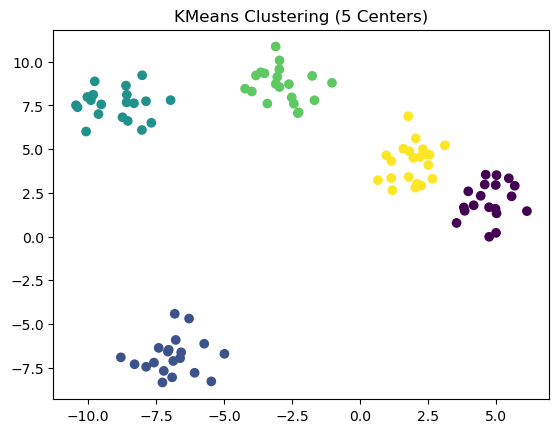

In [34]:
#41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the
# clustering.

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Generate synthetic blobs
X, _ = make_blobs(n_samples=100, centers=5, random_state=42)

# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

# Calculate Silhouette Score
sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score}")

# Visualize the clustering results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("KMeans Clustering (5 Centers)")
plt.show()


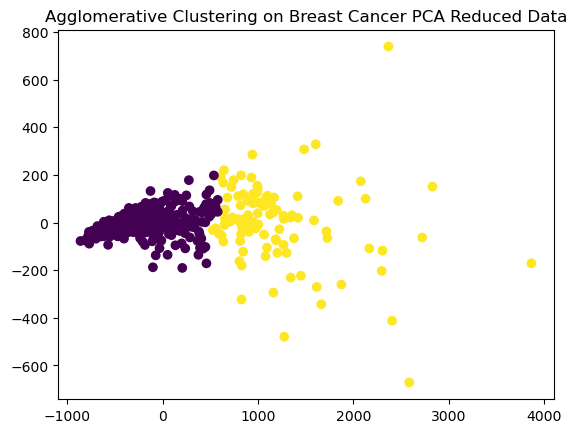

In [35]:
#42.Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering.
#Visualize in 2D.

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data

# Reduce dimensionality using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=2)
labels = agg_clust.fit_predict(X_pca)

# Visualize in 2D
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.title("Agglomerative Clustering on Breast Cancer PCA Reduced Data")
plt.show()


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


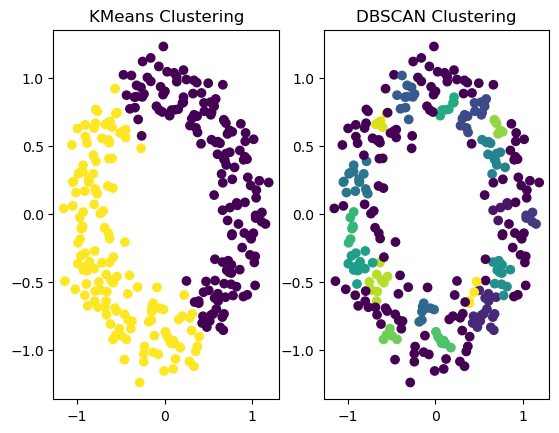

In [36]:
#43.Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN
#side-by-side.
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

# Generate noisy circular data
X, _ = make_circles(n_samples=300, noise=0.1)

# KMeans Clustering
kmeans = KMeans(n_clusters=2)
kmeans_labels = kmeans.fit_predict(X)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Plot KMeans Results
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.title("KMeans Clustering")

# Plot DBSCAN Results
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
plt.title("DBSCAN Clustering")

plt.show()


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


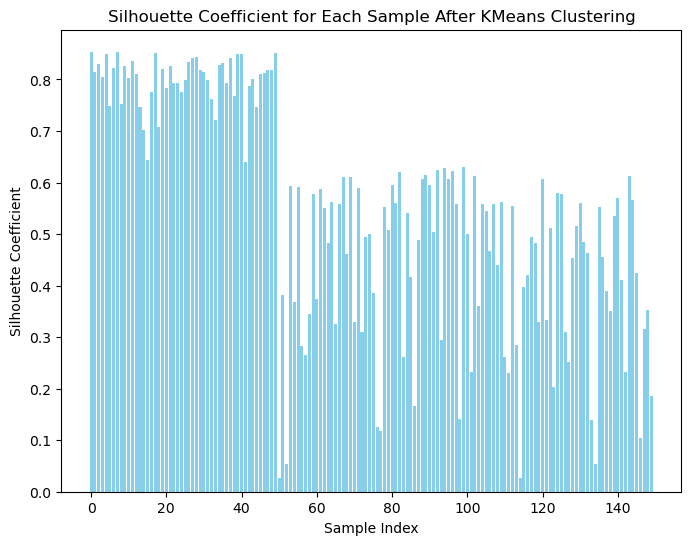

In [42]:
#44.Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# Load the Iris dataset
iris = load_iris()
X = iris.data

# Apply KMeans clustering (assuming 3 clusters for the Iris dataset)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Compute the Silhouette Coefficient for each sample
silhouette_vals = silhouette_samples(X, labels)

# Plot the Silhouette Coefficients
plt.figure(figsize=(8, 6))
plt.bar(range(len(silhouette_vals)), silhouette_vals, color='skyblue')
plt.xlabel('Sample Index')
plt.ylabel('Silhouette Coefficient')
plt.title('Silhouette Coefficient for Each Sample After KMeans Clustering')
plt.show()


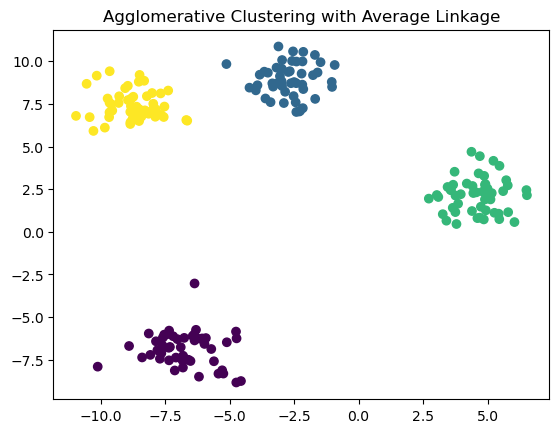

In [38]:
#45.Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage.
#Visualize clusters.

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Generate synthetic data
X, _ = make_blobs(n_samples=200, centers=4, random_state=42)

# Apply Agglomerative Clustering with 'average' linkage
agg_clust = AgglomerativeClustering(n_clusters=4, linkage='average')
labels = agg_clust.fit_predict(X)

# Visualize clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("Agglomerative Clustering with Average Linkage")
plt.show()


C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\PC DOCTOR\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before o

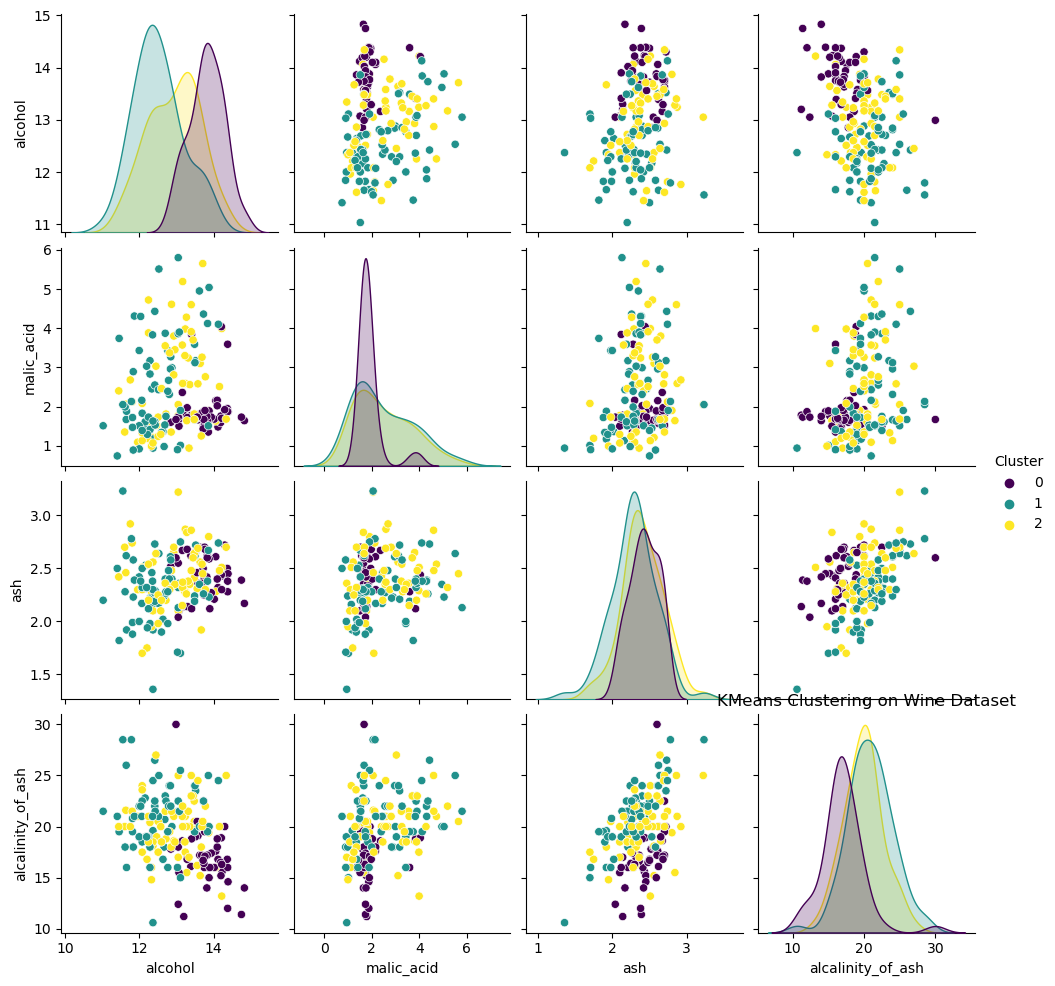

In [39]:
#46.Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4
#features).

from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
import seaborn as sns
import pandas as pd

# Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# Apply KMeans
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

# Create a DataFrame with the first 4 features and the cluster labels
df = pd.DataFrame(X[:, :4], columns=wine.feature_names[:4])
df['Cluster'] = labels

# Visualize with Seaborn Pairplot
sns.pairplot(df, hue='Cluster', palette='viridis')
plt.title("KMeans Clustering on Wine Dataset")
plt.show()


Number of clusters: 3
Number of noise points: 31


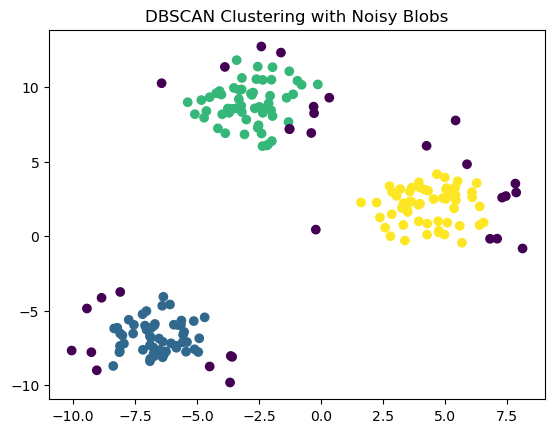

In [40]:
#47.Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the
#count.
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

# Generate noisy blobs
X, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.5, random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=1.0, min_samples=5)
labels = dbscan.fit_predict(X)

# Count clusters and noise points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Visualize the clusters and noise points
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("DBSCAN Clustering with Noisy Blobs")
plt.show()


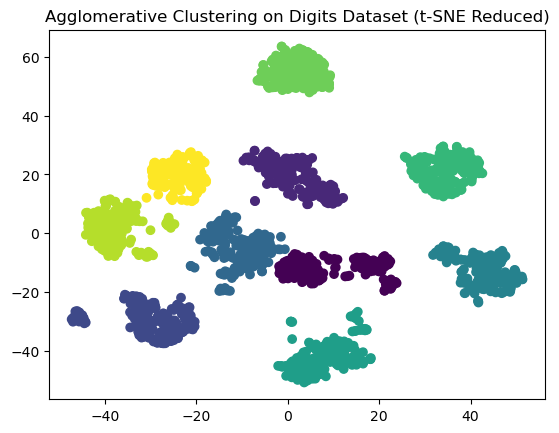

In [41]:
#48.Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the
#clusters.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Load the Digits dataset
digits = load_digits()
X = digits.data

# Reduce dimensionality using PCA and t-SNE
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_pca)

# Apply Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=10)
labels = agg_clust.fit_predict(X_tsne)

# Visualize clusters
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis')
plt.title("Agglomerative Clustering on Digits Dataset (t-SNE Reduced)")
plt.show()
